# Stryde EDA and Forecasting

## Exploratory Data Analysis
Before building any model, we explore the data to:
1. Confirm it's correctly loaded
2. Check for any missing or inconsistent values
3. Understand the different categories and KPIs available
4. Get a visual understanding of the overall trends

### 1. Import Required Libraries and Setting Plot Formats

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

In [2]:
# Setting global formatting for all plots
plt.rcParams.update({
    'figure.facecolor': '#f8f9fb',
    'axes.facecolor':   '#ffffff',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.grid':         True,
    'grid.color':        '#f0f2f5',
    'grid.linewidth':    0.8,
    'font.family':       'Arial',
    'axes.labelcolor':   '#8a95a3',
    'xtick.color':       '#8a95a3',
    'ytick.color':       '#8a95a3',
})

REGION_COLORS = {
    'Southeast': '#2e9e8f',
    'Midwest':   '#d96b4f',
    'South':     '#e8a838',
    'Northeast': '#4a6fa5',
    'West':      '#7b5ea7'
}
RETAILER_COLORS = {
    'Walmart':       '#7ec8e3',
    'Amazon':        '#8b6fbe',
    "Kohl's":        '#e8614d',
    'West Gear':     '#1fa8a0',
    'Sports Direct': '#f0b429',
    'Foot Locker':   '#3a7fc1'
}

# File Path



### 2. Load and Clean Data

In [3]:
df = pd.read_csv(r'C:\Users\dlugo\Google Drive\My Drive\Portfolio Projects\Stryde Sales Analysis and Forecasting\Stryde_US_Sales_Dataset.csv')

# Convert Invoice date from a string to a panda's datetime
# Make a Year and Month column so we can easily group by them later
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], format='%m/%d/%Y')
df['Year'] = df['Invoice Date'].dt.year
df['Month'] = df['Invoice Date'].dt.month

# Remove commas from currency columns (e.g. 1,200 -> 1200)
df['Total Sales']      = df['Total Sales'].astype(str).str.replace(',', '').astype(float)
df['Operating Profit'] = df['Operating Profit'].astype(str).str.replace(',', '').astype(float)
df['Operating Margin'] = df['Operating Margin'].astype(str).str.replace('%', '').astype(float)

### 3. Basic Data Checks

In [4]:
# How many rows and columns in the data source
print(f"\n Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# What is the date range for the data source
print(f"\n Date range: {df['Invoice Date'].min().date()} → {df['Invoice Date'].max().date()}")

# Any missing values
print(f"\n Missing values per column:")
print(df.isnull().sum().to_string())

# What are the unique categories that exist for each column
print(f"\n Unique categories:")
for col in ['Retailer', 'Region', 'Product', 'Sales Method']:
    print(f"   {col}: {sorted(df[col].unique().tolist())}")


 Shape: 16,669 rows × 15 columns

 Date range: 2022-01-01 → 2023-12-31

 Missing values per column:
Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
Year                0
Month               0

 Unique categories:
   Retailer: ['Amazon', 'Foot Locker', "Kohl's", 'Sports Direct', 'Walmart', 'West Gear']
   Region: ['Midwest', 'Northeast', 'South', 'Southeast', 'West']
   Product: ["Men's Apparel", "Men's Athletic Footwear", "Men's Street Footwear", "Women's Apparel", "Women's Athletic Footwear", "Women's Street Footwear"]
   Sales Method: ['In-store', 'Online', 'Outlet']


In [5]:
# Summary Statistics, quickly identify any outliers or anything that looks suspicious
print(df[['Price per Unit', 'Units Sold', 'Total Sales',
          'Operating Profit', 'Operating Margin']].describe().round(2).to_string())

       Price per Unit  Units Sold  Total Sales  Operating Profit  Operating Margin
count        16669.00    16669.00     16669.00          16669.00          16669.00
mean            44.87      149.12      6744.94           2843.16             42.50
std             14.63       93.76      5033.76           2226.92              9.62
min              7.00        0.00         0.00              0.00             10.00
25%             35.00       86.00      3200.00           1299.00             35.00
50%             45.00      133.00      5800.00           2386.00             42.00
75%             55.00      198.00      9065.00           3784.00             49.00
max            110.00     1050.00     56700.00          26730.00             80.00


Price per Unit: Ranges between 7 and 110, with the mean being 44.87. Nothing strange as the price of goods can vary widley

Units Sold: Mean of 149, max of 1,050. The minimum being 0 is odd as transactions with 0 units shouldn't exist. We'll check later.

Total Sales: The mean is 6744.94 and the median is 5800. There are some outliers pulling the mean up but, nothing too extreme.

Operating Profit: Ranges from 10% to 80%, there are some transactions with very high Operating Margin.

In [6]:
# Check the 0 units sold
zeros = df[df['Units Sold'] == 0]
print(zeros[['Retailer', 'Region', 'Product', 'Units Sold', 'Total Sales', 'Operating Profit']].to_string())

          Retailer   Region                    Product  Units Sold  Total Sales  Operating Profit
11864  Foot Locker  Midwest  Women's Athletic Footwear           0          0.0               0.0
11880  Foot Locker  Midwest  Women's Athletic Footwear           0          0.0               0.0
12035  Foot Locker  Midwest  Women's Athletic Footwear           0          0.0               0.0
12041  Foot Locker  Midwest  Women's Athletic Footwear           0          0.0               0.0


Only 4 transactions with 0 units sold and the Sales/Profit is 0 as well. Lets remove them from the dataframe so it doesn't interfere with our calculations later.

In [7]:
# Remove rows where Units Sold is <= 0
df = df[df['Units Sold'] > 0]

### 3. Annual Totals

In [8]:
# Split data into groups based on years
yearly = df.groupby('Year').agg(
    Total_Sales   = ('Total Sales',      'sum'),
    Total_Profit  = ('Operating Profit', 'sum'),
    Total_Units   = ('Units Sold',       'sum')
).reset_index()

# Calculate true margin as Total Profit / Total Sales
yearly['Avg_Margin'] = (yearly['Total_Profit'] / yearly['Total_Sales'] * 100).round(1)

for _, row in yearly.iterrows():
    print(f"   {int(row.Year)} → "
          f"Sales: ${row.Total_Sales/1e6:.2f}M | "
          f"Profit: ${row.Total_Profit/1e6:.2f}M | "
          f"Margin: {row.Avg_Margin:.1f}% | "
          f"Units: {row.Total_Units/1e6:.1f}M")

   2022 → Sales: $60.01M | Profit: $25.41M | Margin: 42.4% | Units: 1.3M
   2023 → Sales: $52.43M | Profit: $21.98M | Margin: 41.9% | Units: 1.2M


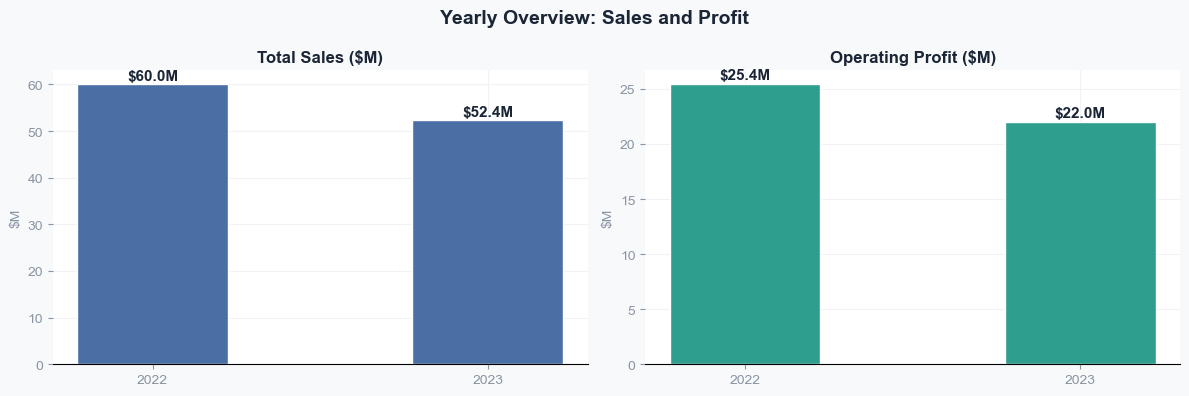

In [9]:
# Visualize our yearly overview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Yearly Overview: Sales and Profit', fontsize=14,
             fontweight='bold', color='#1a2535')

for ax, metric, label, color in zip(
    axes,
    ['Total_Sales', 'Total_Profit'],
    ['Total Sales ($M)', 'Operating Profit ($M)'],
    ['#4a6fa5', '#2e9e8f']
):
    bars = ax.bar(yearly['Year'].astype(str), yearly[metric] / 1e6,
                  color=color, width=0.45, edgecolor='white')
    ax.set_title(label, fontsize=12, fontweight='bold', color='#1a2535')
    ax.set_ylabel('$M', color='#8a95a3')
    ax.set_axisbelow(True)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f'${bar.get_height():.1f}M',
                ha='center', va='bottom',
                fontweight='bold', color='#1a2535', fontsize=11)

plt.tight_layout()
plt.savefig('Yearly_Overview.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Monthly Time Series

In [10]:
# Split data into groups based on Year and Month
monthly = df.groupby(['Year', 'Month']).agg(
    Sales  = ('Total Sales',      'sum'),
    Profit = ('Operating Profit', 'sum'),
    Units  = ('Units Sold',       'sum')
).reset_index()

# Recalculate true margin at monthly level
monthly['Margin'] = (monthly['Profit'] / monthly['Sales'] * 100).round(1)

# Build a Date column for the x-axis
monthly['Date'] = pd.to_datetime(
    monthly[['Year', 'Month']].assign(Day=1)
)
monthly = monthly.sort_values('Date')

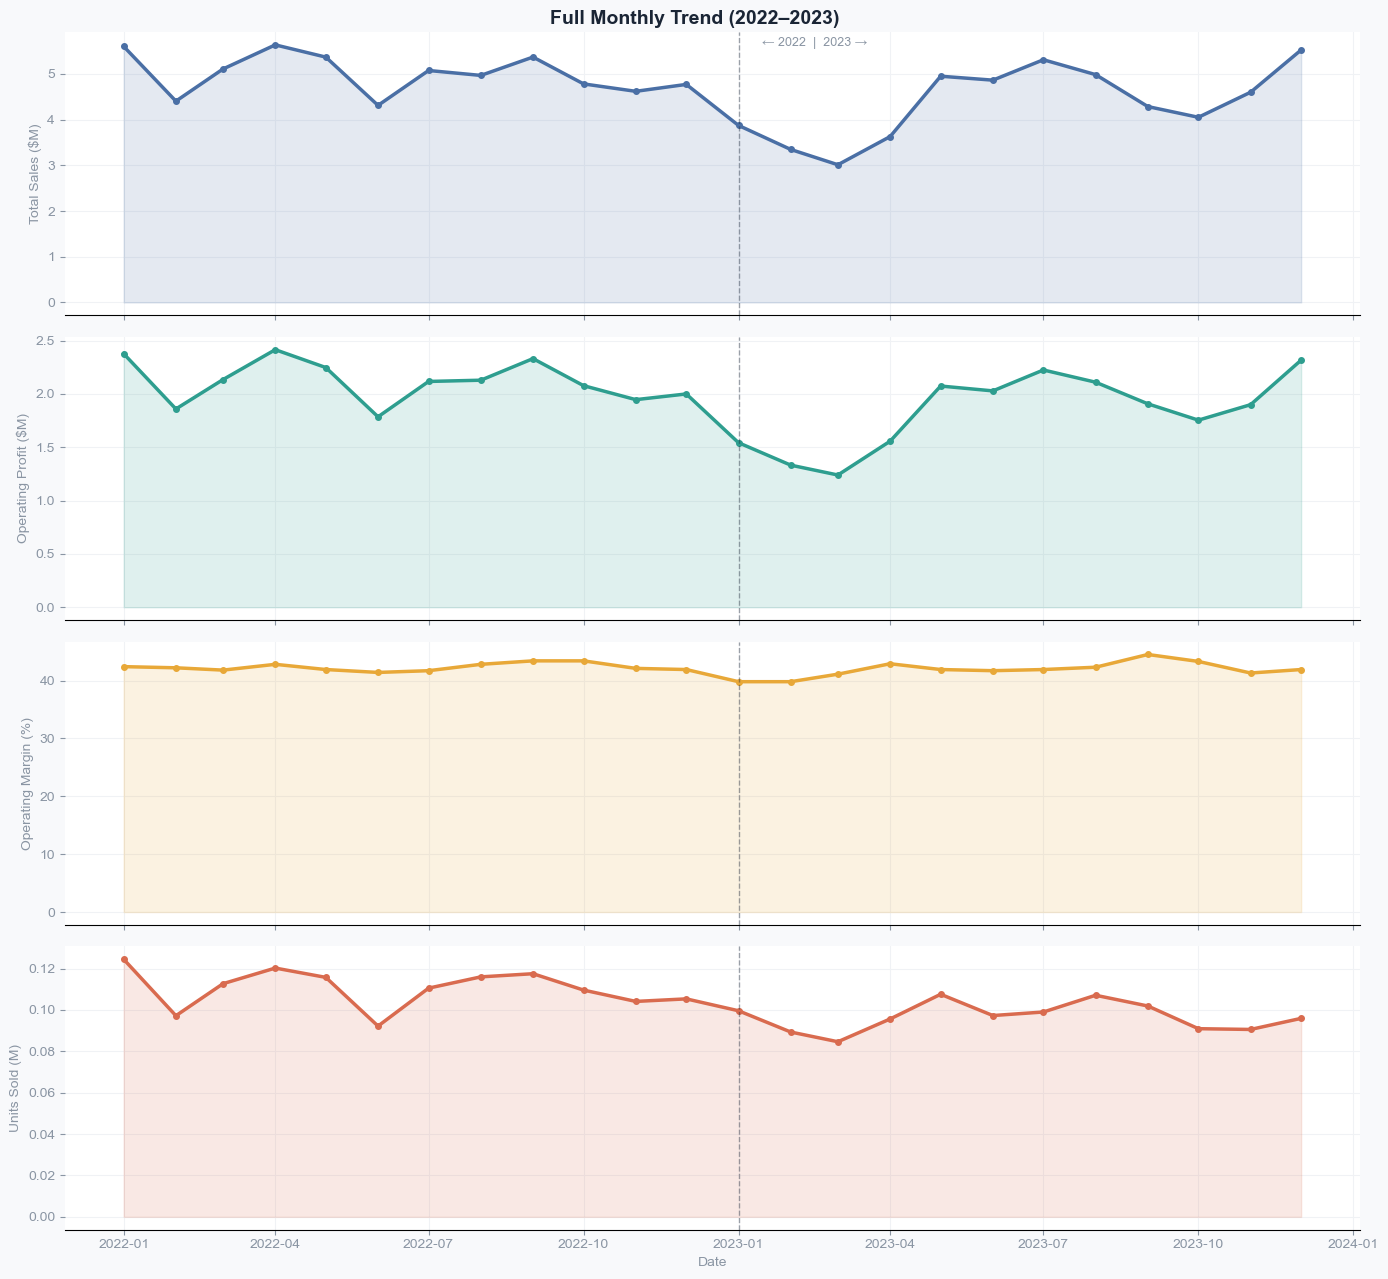

In [11]:
# Visualize our monthly overview
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
fig.suptitle('Full Monthly Trend (2022–2023)',
             fontsize=14, fontweight='bold', color='#1a2535')

for ax, col, label, color in zip(
    axes,
    ['Sales', 'Profit', 'Margin', 'Units'],
    ['Total Sales ($M)', 'Operating Profit ($M)', 'Operating Margin (%)', 'Units Sold (M)'],
    ['#4a6fa5', '#2e9e8f', '#e8a838', '#d96b4f']
):
    scale = 1e6 if col != 'Margin' else 1
    ax.fill_between(monthly['Date'], monthly[col] / scale,
                    alpha=0.15, color=color)
    ax.plot(monthly['Date'], monthly[col] / scale,
            color=color, linewidth=2.5, marker='o', markersize=4)
    ax.set_ylabel(label, color='#8a95a3', fontsize=10)
    ax.set_axisbelow(True)
    ax.axvline(pd.Timestamp('2023-01-01'), color='#1a2535',
               linestyle='--', linewidth=1, alpha=0.4)

# Label the year divider
axes[0].text(pd.Timestamp('2023-01-15'), axes[0].get_ylim()[1] * 0.95,
             '← 2022  |  2023 →', fontsize=9, color='#8a95a3')

axes[-1].set_xlabel('Date', color='#8a95a3')
plt.tight_layout()
plt.savefig('Monthly_Trend.png', dpi=150, bbox_inches='tight')
plt.show()

This is showing the monthly trend from 2022 - 2023. We can see there was a slight dip at the start of 2023 for Operating Profit, Units Sold, and Total Sales. We can see a spike towards the end of 2023. We see operating margin stayed even at around 42% from 2022 to 2023.

## Performance Scorecard
Prior to building the forecasting model, the scorecard will:
1. Allow us to identify top, mid, and bottom performers
2. We will be able to feed this information into our forecast to answer the question of how KPIs would look if we reallocated 20% of our resources away from bottom performers

### 1. Calculate 2022 and 2023 by Retailer

In [12]:
# Separate 2022 and 2023 data
df_2022 = df[df['Year'] == 2022]
df_2023 = df[df['Year'] == 2023]

# Aggregate per year, per retailer
def get_kpi(data):
    agg = data.groupby('Retailer').agg(
        Sales  = ('Total Sales',      'sum'),
        Profit = ('Operating Profit', 'sum'),
        Units  = ('Units Sold',       'sum')
    ).reset_index()
    agg['Margin'] = (agg['Profit'] / agg['Sales'] * 100).round(2)
    return agg

kpi_2022 = get_kpi(df_2022)
kpi_2023 = get_kpi(df_2023)

print(kpi_2022)
print(kpi_2023)

        Retailer       Sales     Profit   Units  Margin
0         Amazon   5188118.0  2228713.0  119735   42.96
1    Foot Locker  16037986.0  6885724.0  358674   42.93
2         Kohl's   5905425.0  2541920.0  132719   43.04
3  Sports Direct  13091009.0  5574370.0  296511   42.58
4        Walmart   4326223.0  1850959.0   98467   42.78
5      West Gear  15457527.0  6331012.0  319805   40.96
        Retailer       Sales     Profit   Units  Margin
0         Amazon   5803352.0  2366281.0  117671   40.77
1    Foot Locker  13689000.0  5593214.0  298024   40.86
2         Kohl's   6824830.0  2812128.0  151025   41.20
3  Sports Direct  12369671.0  5568383.0  291120   45.02
4        Walmart   2977560.0  1133321.0   59919   38.06
5      West Gear  10760782.0  4506686.0  241953   41.88


In [13]:
# Merge 2022 and 2023 together
scorecard = kpi_2022.merge(kpi_2023, on='Retailer', suffixes=('_2022', '_2023'))

# Calculate YoY growth rates
scorecard['Sales_Growth']  = ((scorecard['Sales_2023']  - scorecard['Sales_2022'])  / scorecard['Sales_2022']  * 100).round(2)
scorecard['Profit_Growth'] = ((scorecard['Profit_2023'] - scorecard['Profit_2022']) / scorecard['Profit_2022'] * 100).round(2)
scorecard['Units_Growth']  = ((scorecard['Units_2023']  - scorecard['Units_2022'])  / scorecard['Units_2022']  * 100).round(2)
scorecard['Margin_Growth'] = ((scorecard['Margin_2023'] - scorecard['Margin_2022']) / scorecard['Margin_2022'] * 100).round(2)

print(scorecard[['Retailer', 'Sales_Growth', 'Profit_Growth', 'Units_Growth', 'Margin_Growth']])

        Retailer  Sales_Growth  Profit_Growth  Units_Growth  Margin_Growth
0         Amazon         11.86           6.17         -1.72          -5.10
1    Foot Locker        -14.65         -18.77        -16.91          -4.82
2         Kohl's         15.57          10.63         13.79          -4.28
3  Sports Direct         -5.51          -0.11         -1.82           5.73
4        Walmart        -31.17         -38.77        -39.15         -11.03
5      West Gear        -30.38         -28.82        -24.34           2.25


### 2. Build Composite Score per Retailer

In [14]:
score_cols = ['Sales_2023', 'Profit_2023', 'Units_2023',
              'Margin_2023', 'Sales_Growth', 'Profit_Growth',
              'Units_Growth', 'Margin_Growth']

# Normalize each kpi to 0-100 scale
scaler = MinMaxScaler(feature_range=(0, 100))
scaled = scaler.fit_transform(scorecard[score_cols])
scaled_df = pd.DataFrame(scaled, columns=score_cols)

# Composite score = average across all normalized kpis
scorecard['Composite_Score'] = scaled_df.mean(axis=1).round(2)

# Tier each retailer
def assign_tier(score):
    if score >= 60:
        return 'Top'
    elif score >= 45:
        return 'Mid'
    else:
        return 'Bottom'

scorecard['Tier'] = scorecard['Composite_Score'].apply(assign_tier)

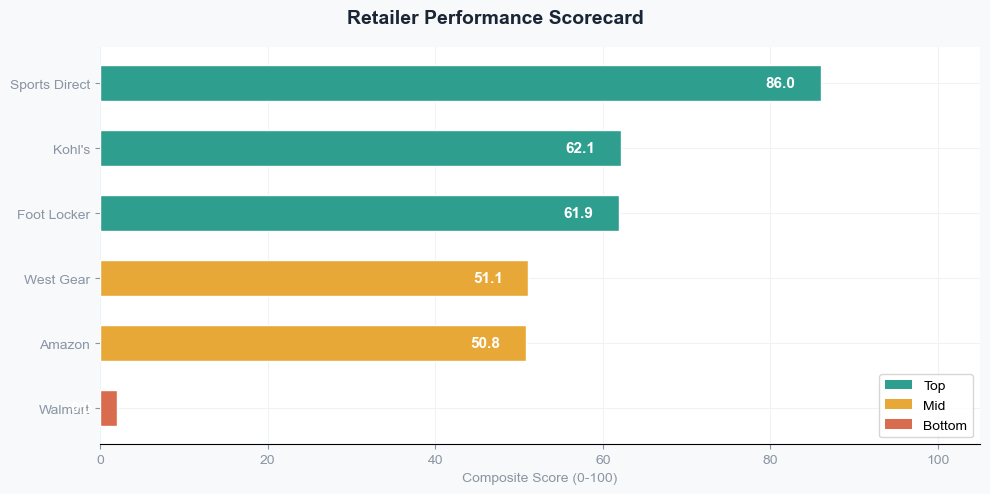

In [15]:
sorted_df = scorecard.sort_values('Composite_Score', ascending=True)

# Visualize score card
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Retailer Performance Scorecard', fontsize=14,
             fontweight='bold', color='#1a2535')

tier_colors = {'Top': '#2e9e8f', 'Mid': '#e8a838', 'Bottom': '#d96b4f'}

sorted_df['Display_Score'] = sorted_df['Composite_Score'].apply(
    lambda x: max(x, 2)
)

bars = ax.barh(sorted_df['Retailer'], sorted_df['Display_Score'],
               color=[tier_colors[t] for t in sorted_df['Tier']],
               edgecolor='white', height=0.55)

# Add score labels on the bars
for bar, score, tier in zip(bars, sorted_df['Composite_Score'], sorted_df['Tier']):
    ax.text(bar.get_width() - 3, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', ha='right',
            fontweight='bold', color='white', fontsize=11)

# Add tier legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Composite Score (0-100)', color='#8a95a3')
ax.set_xlim(0, 105)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('step2_retailer_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Build Composite Score per Region

In [16]:
def get_kpi_region(data):
    agg = data.groupby('Region').agg(
        Sales  = ('Total Sales',      'sum'),
        Profit = ('Operating Profit', 'sum'),
        Units  = ('Units Sold',       'sum')
    ).reset_index()
    agg['Margin'] = (agg['Profit'] / agg['Sales'] * 100).round(2)
    return agg

kpi_region_2022 = get_kpi_region(df_2022)
kpi_region_2023 = get_kpi_region(df_2023)

# Calculate growth per region
region_scorecard = kpi_region_2022.merge(
    kpi_region_2023, on='Region', suffixes=('_2022', '_2023')
)
region_scorecard['Sales_Growth']  = ((region_scorecard['Sales_2023']  - region_scorecard['Sales_2022'])  / region_scorecard['Sales_2022']  * 100).round(2)
region_scorecard['Profit_Growth'] = ((region_scorecard['Profit_2023'] - region_scorecard['Profit_2022']) / region_scorecard['Profit_2022'] * 100).round(2)
region_scorecard['Units_Growth']  = ((region_scorecard['Units_2023']  - region_scorecard['Units_2022'])  / region_scorecard['Units_2022']  * 100).round(2)
region_scorecard['Margin_Growth'] = ((region_scorecard['Margin_2023'] - region_scorecard['Margin_2022']) / region_scorecard['Margin_2022'] * 100).round(2)

# Normalize each KPI 0-100
score_cols = ['Sales_2023', 'Profit_2023', 'Units_2023', 'Margin_2023',
              'Sales_Growth', 'Profit_Growth', 'Units_Growth', 'Margin_Growth']
              
scaled = scaler.fit_transform(region_scorecard[score_cols])
scaled_df = pd.DataFrame(scaled, columns=score_cols)
region_scorecard['Composite_Score'] = scaled_df.mean(axis=1).round(2)

# Assign tiers, need seperate tiers from retailers because data distribution is different
def assign_tier_region(score):
    if score >= 55:
        return 'Top'
    elif score >= 40:
        return 'Mid'
    else:
        return 'Bottom'

region_scorecard['Tier'] = region_scorecard['Composite_Score'].apply(assign_tier_region)

print(region_scorecard[['Region', 'Composite_Score', 'Tier']].sort_values(
    'Composite_Score', ascending=False).to_string())


      Region  Composite_Score    Tier
2      South            59.93     Top
4       West            43.69     Mid
3  Southeast            41.95     Mid
0    Midwest            33.01  Bottom
1  Northeast            31.36  Bottom


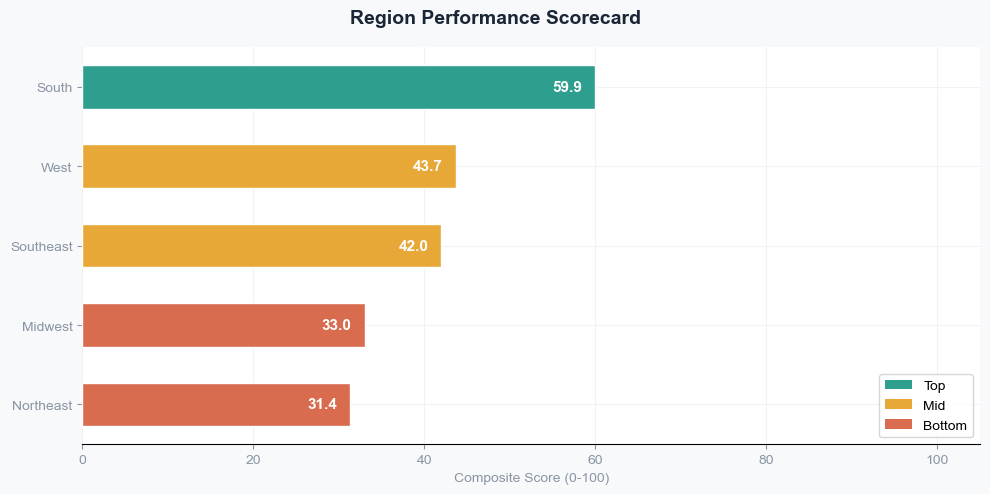

In [17]:
# Visualize score card for regions
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Region Performance Scorecard', fontsize=14,
             fontweight='bold', color='#1a2535')

sorted_regions = region_scorecard.sort_values('Composite_Score', ascending=True)
sorted_regions['Display_Score'] = sorted_regions['Composite_Score'].apply(
    lambda x: max(x, 2)
)

bars = ax.barh(sorted_regions['Region'], sorted_regions['Display_Score'],
               color=[tier_colors[t] for t in sorted_regions['Tier']],
               edgecolor='white', height=0.55)

for bar, score, tier in zip(bars, sorted_regions['Composite_Score'], sorted_regions['Tier']):
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}', va='center', ha='right',
            fontweight='bold', color='white', fontsize=11)

legend_elements = [Patch(facecolor=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.set_xlabel('Composite Score (0-100)', color='#8a95a3')
ax.set_xlim(0, 105)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('step2_region_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Visualize retailer by product
def get_kpi_retailer_product(data):
    agg = data.groupby(['Retailer', 'Product']).agg(
        Sales  = ('Total Sales',      'sum'),
        Profit = ('Operating Profit', 'sum'),
        Units  = ('Units Sold',       'sum')
    ).reset_index()
    agg['Margin'] = (agg['Profit'] / agg['Sales'] * 100).round(2)
    return agg

kpi_rp_2022 = get_kpi_retailer_product(df_2022)
kpi_rp_2023 = get_kpi_retailer_product(df_2023)

# Merge and calculate growth
rp_scorecard = kpi_rp_2022.merge(
    kpi_rp_2023, on=['Retailer', 'Product'], suffixes=('_2022', '_2023')
)

rp_scorecard['Sales_Growth']  = ((rp_scorecard['Sales_2023']  - rp_scorecard['Sales_2022'])  / rp_scorecard['Sales_2022']  * 100).round(2)
rp_scorecard['Profit_Growth'] = ((rp_scorecard['Profit_2023'] - rp_scorecard['Profit_2022']) / rp_scorecard['Profit_2022'] * 100).round(2)
rp_scorecard['Units_Growth']  = ((rp_scorecard['Units_2023']  - rp_scorecard['Units_2022'])  / rp_scorecard['Units_2022']  * 100).round(2)
rp_scorecard['Margin_Growth'] = ((rp_scorecard['Margin_2023'] - rp_scorecard['Margin_2022']) / rp_scorecard['Margin_2022'] * 100).round(2)

# Normalize and score
scaled = scaler.fit_transform(rp_scorecard[score_cols])
scaled_df = pd.DataFrame(scaled, columns=score_cols)
rp_scorecard['Composite_Score'] = scaled_df.mean(axis=1).round(2)

# Assign tiers
rp_scorecard['Tier'] = rp_scorecard['Composite_Score'].apply(assign_tier)

print(rp_scorecard[['Retailer', 'Product', 'Composite_Score', 'Tier']].sort_values(
    'Composite_Score', ascending=False).head(10).to_string())

         Retailer                  Product  Composite_Score Tier
21  Sports Direct          Women's Apparel            78.13  Top
8     Foot Locker    Men's Street Footwear            75.00  Top
20  Sports Direct    Men's Street Footwear            71.27  Top
2          Amazon    Men's Street Footwear            67.42  Top
14         Kohl's    Men's Street Footwear            63.74  Top
9     Foot Locker          Women's Apparel            56.61  Mid
12         Kohl's            Men's Apparel            56.34  Mid
19  Sports Direct  Men's Athletic Footwear            56.32  Mid
32      West Gear    Men's Street Footwear            54.91  Mid
33      West Gear          Women's Apparel            53.23  Mid


In [19]:
# Lets check the top 10 and bottom 10 to get a better idea
print("TOP 10:")
print(rp_scorecard[['Retailer', 'Product', 'Composite_Score', 'Tier']].sort_values(
    'Composite_Score', ascending=False).head(10).to_string())

print("\nBOTTOM 10:")
print(rp_scorecard[['Retailer', 'Product', 'Composite_Score', 'Tier']].sort_values(
    'Composite_Score', ascending=True).head(10).to_string())

TOP 10:
         Retailer                  Product  Composite_Score Tier
21  Sports Direct          Women's Apparel            78.13  Top
8     Foot Locker    Men's Street Footwear            75.00  Top
20  Sports Direct    Men's Street Footwear            71.27  Top
2          Amazon    Men's Street Footwear            67.42  Top
14         Kohl's    Men's Street Footwear            63.74  Top
9     Foot Locker          Women's Apparel            56.61  Mid
12         Kohl's            Men's Apparel            56.34  Mid
19  Sports Direct  Men's Athletic Footwear            56.32  Mid
32      West Gear    Men's Street Footwear            54.91  Mid
33      West Gear          Women's Apparel            53.23  Mid

BOTTOM 10:
   Retailer                    Product  Composite_Score    Tier
24  Walmart              Men's Apparel             2.89  Bottom
28  Walmart  Women's Athletic Footwear            13.48  Bottom
29  Walmart    Women's Street Footwear            14.70  Bottom
25  Walma

## Forecasting with Prophet
We will be forcasting with Prophet. We'll generate 2 forecasts:
1. Baseline forecast using the 24 months worth of data
2. Forecast using the proposed reallocation of resources
* Due to limited data (only 2 years), confidence intervals will be wider

In [20]:
from prophet import Prophet

### 1. Preparing Data for Forecasting

In [21]:
# Aggregate to monthly total sales across the whole organization
prophet_df = df.groupby(['Year', 'Month']).agg(
    y = ('Total Sales', 'sum')
).reset_index()

# Build the 'ds' date column Prophet requires
prophet_df['ds'] = pd.to_datetime(
    prophet_df[['Year', 'Month']].assign(Day=1)
)

prophet_df = prophet_df[['ds', 'y']].sort_values('ds')

print(f"Rows: {len(prophet_df)}")
print(prophet_df.to_string())

Rows: 24
           ds          y
0  2022-01-01  5601170.0
1  2022-02-01  4403799.0
2  2022-03-01  5108103.0
3  2022-04-01  5634898.0
4  2022-05-01  5367288.0
5  2022-06-01  4311177.0
6  2022-07-01  5074489.0
7  2022-08-01  4966805.0
8  2022-09-01  5368325.0
9  2022-10-01  4781302.0
10 2022-11-01  4618819.0
11 2022-12-01  4770113.0
12 2023-01-01  3872741.0
13 2023-02-01  3346580.0
14 2023-03-01  3012117.0
15 2023-04-01  3628559.0
16 2023-05-01  4949326.0
17 2023-06-01  4863168.0
18 2023-07-01  5309586.0
19 2023-08-01  4983891.0
20 2023-09-01  4285258.0
21 2023-10-01  4050809.0
22 2023-11-01  4598925.0
23 2023-12-01  5524235.0


### 2. Baseline Forecast

In [22]:
model = Prophet(
    interval_width=0.95,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

model.add_seasonality(
    name='yearly',
    period=365.25,
    fourier_order=3
)

model.fit(prophet_df)

future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

forecast_2024 = forecast[forecast['ds'].dt.year == 2024][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].reset_index(drop=True)

forecast_2024.columns = ['Date', 'Forecast', 'Lower_Bound', 'Upper_Bound']
forecast_2024['Forecast']    = forecast_2024['Forecast'].round(0)
forecast_2024['Lower_Bound'] = forecast_2024['Lower_Bound'].round(0)
forecast_2024['Upper_Bound'] = forecast_2024['Upper_Bound'].round(0)

print(forecast_2024.to_string())

10:34:52 - cmdstanpy - INFO - Chain [1] start processing
10:34:52 - cmdstanpy - INFO - Chain [1] done processing


         Date   Forecast  Lower_Bound  Upper_Bound
0  2024-01-01  3922295.0    2932393.0    4877267.0
1  2024-02-01  2962925.0    2052538.0    3927502.0
2  2024-03-01  3087863.0    2087450.0    3995155.0
3  2024-04-01  3858228.0    2889916.0    4767389.0
4  2024-05-01  4073785.0    3115675.0    5011699.0
5  2024-06-01  3888092.0    2885231.0    4848473.0
6  2024-07-01  4056583.0    3047245.0    5016628.0
7  2024-08-01  4240855.0    3283839.0    5185693.0
8  2024-09-01  3818434.0    2936489.0    4807124.0
9  2024-10-01  3464191.0    2484879.0    4448183.0
10 2024-11-01  3839543.0    2882389.0    4814987.0
11 2024-12-01  4084424.0    3050682.0    5030652.0


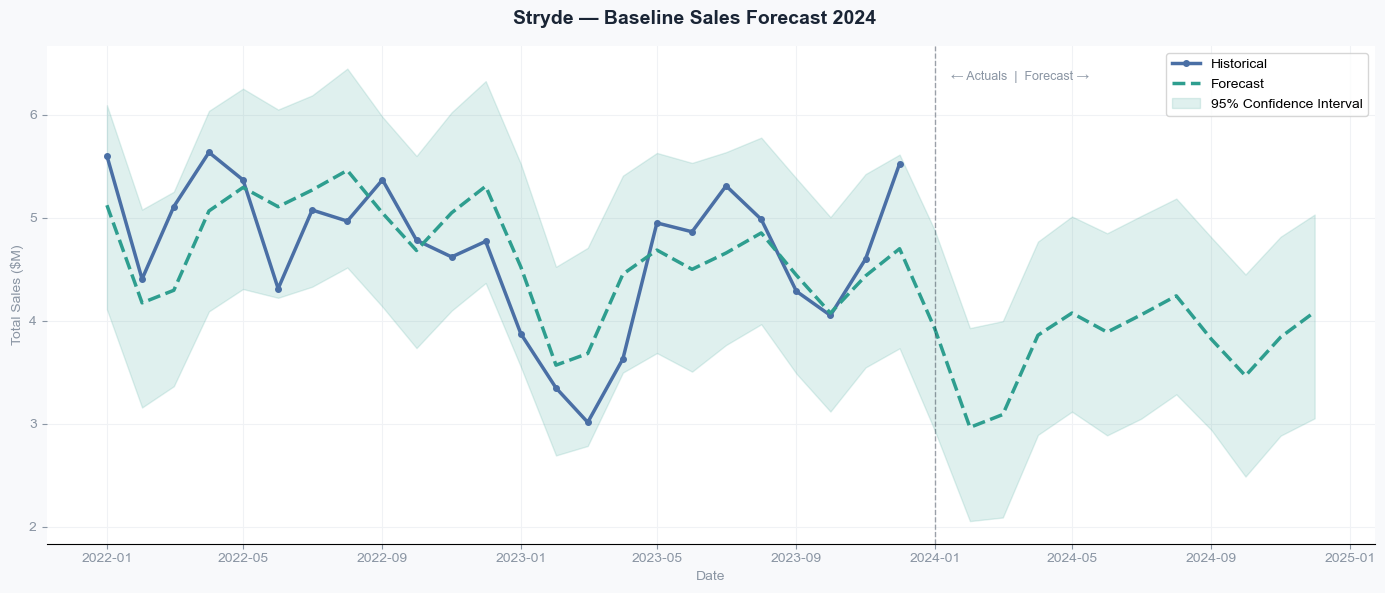

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Stryde — Baseline Sales Forecast 2024',
             fontsize=14, fontweight='bold', color='#1a2535')

# Historical
ax.plot(prophet_df['ds'], prophet_df['y'] / 1e6,
        color='#4a6fa5', linewidth=2.5,
        marker='o', markersize=4, label='Historical')

# Forecast line
forecast_all = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
ax.plot(forecast_all['ds'], forecast_all['yhat'] / 1e6,
        color='#2e9e8f', linewidth=2.5,
        linestyle='--', label='Forecast')

# Confidence interval
ax.fill_between(forecast_all['ds'],
                forecast_all['yhat_lower'] / 1e6,
                forecast_all['yhat_upper'] / 1e6,
                alpha=0.15, color='#2e9e8f',
                label='95% Confidence Interval')

# Year divider
ax.axvline(pd.Timestamp('2024-01-01'), color='#1a2535',
           linestyle='--', linewidth=1, alpha=0.4)
ax.text(pd.Timestamp('2024-01-15'), ax.get_ylim()[1] * 0.95,
        '← Actuals  |  Forecast →',
        fontsize=9, color='#8a95a3')

ax.set_ylabel('Total Sales ($M)', color='#8a95a3')
ax.set_xlabel('Date', color='#8a95a3')
ax.legend(fontsize=10)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('step3_baseline_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Reallocation Scenario
Question: What does 2024 look like if we shift 20% of resources 
from bottom performers to top performers

In [25]:
# Reallocation multipliers based on scorecard tiers
REALLOCATION = {
    'Top':    1.20,   # +20%
    'Mid':    1.00,   # no change
    'Bottom': 0.80    # -20%
}

# Build forecast per retailer
retailer_forecasts = []

for retailer in df['Retailer'].unique():
    
    # Get this retailer's historical monthly sales
    retailer_df = df[df['Retailer'] == retailer].groupby(
        ['Year', 'Month']
    ).agg(y=('Total Sales', 'sum')).reset_index()
    
    retailer_df['ds'] = pd.to_datetime(
        retailer_df[['Year', 'Month']].assign(Day=1)
    )
    retailer_df = retailer_df[['ds', 'y']].sort_values('ds')
    
    # Get this retailer's tier from the scorecard
    tier = scorecard[scorecard['Retailer'] == retailer]['Tier'].values[0]
    multiplier = REALLOCATION[tier]
    
    # Fit Prophet model for this retailer
    m = Prophet(
        interval_width=0.95,
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05
    )
    m.add_seasonality(name='yearly', period=365.25, fourier_order=3)
    m.fit(retailer_df)
    
    # Generate 2024 forecast
    future = m.make_future_dataframe(periods=12, freq='MS')
    fc = m.predict(future)
    fc_2024 = fc[fc['ds'].dt.year == 2024][['ds', 'yhat']].copy()
    
    # Apply reallocation multiplier
    fc_2024['yhat_reallocated'] = fc_2024['yhat'] * multiplier
    fc_2024['Retailer'] = retailer
    fc_2024['Tier'] = tier
    fc_2024['Multiplier'] = multiplier
    
    retailer_forecasts.append(fc_2024)
    print(f"✓ {retailer} ({tier}) — multiplier: {multiplier}")

# Combine each individual retailer forecast
all_forecasts = pd.concat(retailer_forecasts, ignore_index=True)

10:39:28 - cmdstanpy - INFO - Chain [1] start processing
10:39:28 - cmdstanpy - INFO - Chain [1] done processing
10:39:28 - cmdstanpy - INFO - Chain [1] start processing
10:39:28 - cmdstanpy - INFO - Chain [1] done processing
10:39:28 - cmdstanpy - INFO - Chain [1] start processing
10:39:28 - cmdstanpy - INFO - Chain [1] done processing


✓ Foot Locker (Top) — multiplier: 1.2
✓ West Gear (Mid) — multiplier: 1.0
✓ Sports Direct (Top) — multiplier: 1.2


10:39:28 - cmdstanpy - INFO - Chain [1] start processing
10:39:28 - cmdstanpy - INFO - Chain [1] done processing
10:39:28 - cmdstanpy - INFO - Chain [1] start processing
10:39:28 - cmdstanpy - INFO - Chain [1] done processing
10:39:28 - cmdstanpy - INFO - Chain [1] start processing
10:39:28 - cmdstanpy - INFO - Chain [1] done processing


✓ Kohl's (Top) — multiplier: 1.2
✓ Amazon (Mid) — multiplier: 1.0
✓ Walmart (Bottom) — multiplier: 0.8


In [26]:
# Aggregate monthly totals
scenario = all_forecasts.groupby('ds').agg(
    Baseline_Sales     = ('yhat',             'sum'),
    Reallocation_Sales = ('yhat_reallocated', 'sum')
).reset_index()

scenario['ds'] = pd.to_datetime(scenario['ds'])

# Calculate difference and % increase
scenario['Difference'] = (
    scenario['Reallocation_Sales'] - scenario['Baseline_Sales']
).round(0)
scenario['Uplift_Pct'] = (
    scenario['Difference'] / scenario['Baseline_Sales'] * 100
).round(2)

# Formatting
scenario['Baseline_Sales']     = scenario['Baseline_Sales'].round(0)
scenario['Reallocation_Sales'] = scenario['Reallocation_Sales'].round(0)

print("2024 Baseline vs Reallocation Scenario:")
print(scenario.to_string())
print(f"\nTotal Baseline 2024:     ${scenario['Baseline_Sales'].sum()/1e6:.2f}M")
print(f"Total Reallocation 2024: ${scenario['Reallocation_Sales'].sum()/1e6:.2f}M")
print(f"Total Difference:        ${scenario['Difference'].sum()/1e6:.2f}M")

2024 Baseline vs Reallocation Scenario:
           ds  Baseline_Sales  Reallocation_Sales  Difference  Uplift_Pct
0  2024-01-01       3954110.0           4467132.0    513022.0       12.97
1  2024-02-01       2981953.0           3412122.0    430169.0       14.43
2  2024-03-01       3088605.0           3533574.0    444969.0       14.41
3  2024-04-01       3858659.0           4368129.0    509471.0       13.20
4  2024-05-01       4082599.0           4599632.0    517033.0       12.66
5  2024-06-01       3894315.0           4382571.0    488256.0       12.54
6  2024-07-01       4057953.0           4549519.0    491566.0       12.11
7  2024-08-01       4247989.0           4745214.0    497225.0       11.70
8  2024-09-01       3828726.0           4293417.0    464690.0       12.14
9  2024-10-01       3465654.0           3927212.0    461558.0       13.32
10 2024-11-01       3840306.0           4371263.0    530958.0       13.83
11 2024-12-01       4104497.0           4675688.0    571192.0       13.9

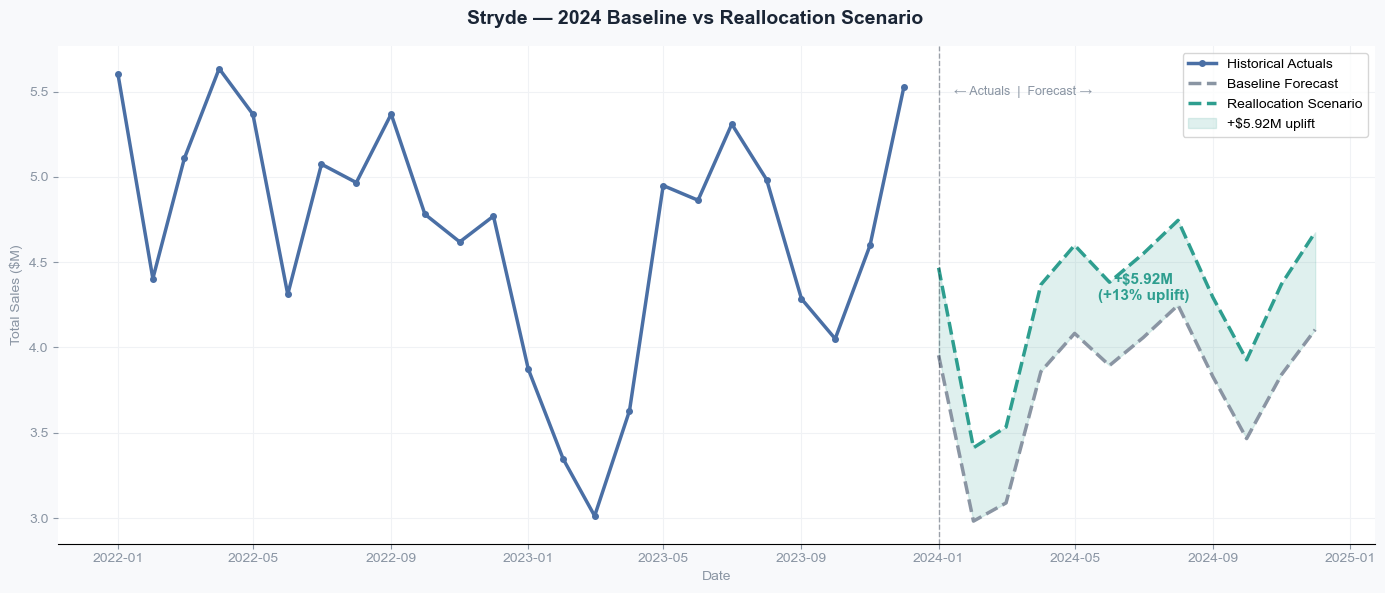

In [27]:
# Visualization of reallocation scenario
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Stryde — 2024 Baseline vs Reallocation Scenario',
             fontsize=14, fontweight='bold', color='#1a2535')

# Plot historical actuals for context
ax.plot(prophet_df['ds'], prophet_df['y'] / 1e6,
        color='#4a6fa5', linewidth=2.5,
        marker='o', markersize=4, label='Historical Actuals')

# Baseline forecast
ax.plot(scenario['ds'], scenario['Baseline_Sales'] / 1e6,
        color='#8a95a3', linewidth=2.5,
        linestyle='--', label='Baseline Forecast')

# Reallocation scenario
ax.plot(scenario['ds'], scenario['Reallocation_Sales'] / 1e6,
        color='#2e9e8f', linewidth=2.5,
        linestyle='--', label='Reallocation Scenario')

# Shade the gap between baseline and scenario
ax.fill_between(scenario['ds'],
                scenario['Baseline_Sales'] / 1e6,
                scenario['Reallocation_Sales'] / 1e6,
                alpha=0.15, color='#2e9e8f',
                label=f'+$5.92M uplift')

# Mark where forecast starts
ax.axvline(pd.Timestamp('2024-01-01'), color='#1a2535',
           linestyle='--', linewidth=1, alpha=0.4)
ax.text(pd.Timestamp('2024-01-15'), ax.get_ylim()[1] * 0.95,
        '← Actuals  |  Forecast →',
        fontsize=9, color='#8a95a3')

# Annotate total uplift
ax.annotate('+$5.92M\n(+13% uplift)',
            xy=(pd.Timestamp('2024-07-01'),
                scenario['Reallocation_Sales'].mean() / 1e6),
            fontsize=11, fontweight='bold', color='#2e9e8f',
            ha='center')

ax.set_ylabel('Total Sales ($M)', color='#8a95a3')
ax.set_xlabel('Date', color='#8a95a3')
ax.legend(fontsize=10)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('step4_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Exporting reallocation scenario for Tableau visualization
scenario_export = scenario.copy()
scenario_export.columns = ['Date', 'Baseline_Sales',
                           'Reallocation_Sales', 'Difference', 'Uplift_Pct']

# Add historical actuals for context
historical = prophet_df.copy()
historical.columns = ['Date', 'Actual_Sales']
scenario_export = scenario_export.merge(historical, on='Date', how='left')

scenario_export.to_csv('stryde_forecast_scenarios.csv', index=False)
print(f"✅ Saved: {len(scenario_export)} rows")
print(scenario_export.to_string())

✅ Saved: 12 rows
         Date  Baseline_Sales  Reallocation_Sales  Difference  Uplift_Pct  Actual_Sales
0  2024-01-01       3954110.0           4467132.0    513022.0       12.97           NaN
1  2024-02-01       2981953.0           3412122.0    430169.0       14.43           NaN
2  2024-03-01       3088605.0           3533574.0    444969.0       14.41           NaN
3  2024-04-01       3858659.0           4368129.0    509471.0       13.20           NaN
4  2024-05-01       4082599.0           4599632.0    517033.0       12.66           NaN
5  2024-06-01       3894315.0           4382571.0    488256.0       12.54           NaN
6  2024-07-01       4057953.0           4549519.0    491566.0       12.11           NaN
7  2024-08-01       4247989.0           4745214.0    497225.0       11.70           NaN
8  2024-09-01       3828726.0           4293417.0    464690.0       12.14           NaN
9  2024-10-01       3465654.0           3927212.0    461558.0       13.32           NaN
10 2024-11-01  